In [38]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [39]:
df = pd.read_csv("../data/raw/Xente_Variable_Definitions.csv")

df.head()

,Column Name,Definition
0,TransactionId,Unique �transaction identifier on platform
1,BatchId,Unique number assigned to a batch of transacti...
2,AccountId,Unique number identifying the customer on plat...
3,SubscriptionId,Unique number identifying the customer subscri...
4,CustomerId,Unique identifier attached to Account


In [40]:
df = pd.read_csv("../data/raw/data.csv")

df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [41]:
print("Shape:", df.shape)

df.info()

Shape: (95662, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object 
 14  PricingStrategy       95662 non-null  int64  
 15  

In [42]:
df.nunique().sort_values(ascending=False)

TransactionId           95662
BatchId                 94809
TransactionStartTime    94556
CustomerId               3742
AccountId                3633
SubscriptionId           3627
Amount                   1676
Value                    1517
ProductId                  23
ProductCategory             9
ProviderId                  6
ChannelId                   4
PricingStrategy             4
FraudResult                 2
CurrencyCode                1
CountryCode                 1
dtype: int64

In [43]:
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

In [44]:
df.duplicated().sum()

0

In [45]:
df["TransactionId"].nunique()
 

95662

In [46]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CountryCode,95662.0,256.000000,0.000000,256.0,256.0,256.0,256.0,256.0
Amount,95662.0,6717.846433,123306.797164,-1000000.0,-50.0,1000.0,2800.0,9880000.0
Value,95662.0,9900.583941,123122.087776,2.0,275.0,1000.0,5000.0,9880000.0
PricingStrategy,95662.0,2.255974,0.732924,0.0,2.0,2.0,2.0,4.0
FraudResult,95662.0,0.002018,0.044872,0.0,0.0,0.0,0.0,1.0


In [47]:
required_columns = [
    "TransactionId",
    "CustomerId",
    "Amount",
    "Value",
    "FraudResult"
]

for col in required_columns:
    assert col in df.columns, \
        f"Missing required column: {col}"

In [48]:
num_cols = [
    "Amount",
    "Value",
    "CountryCode",
    "PricingStrategy"
]

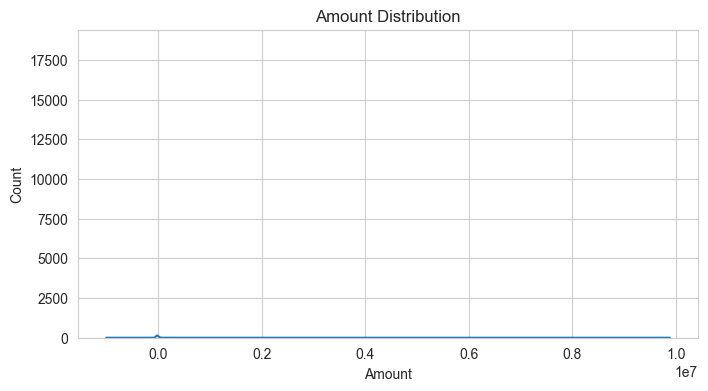

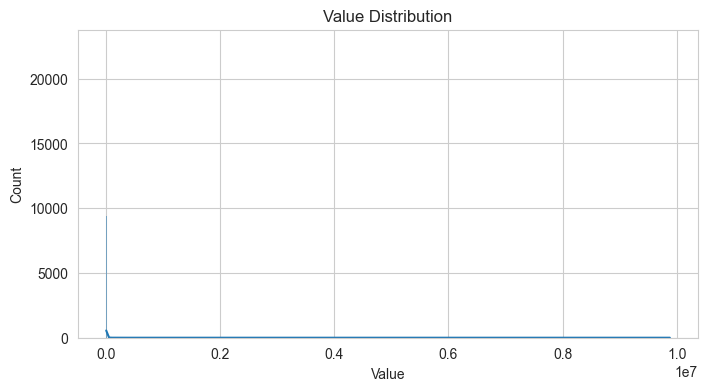

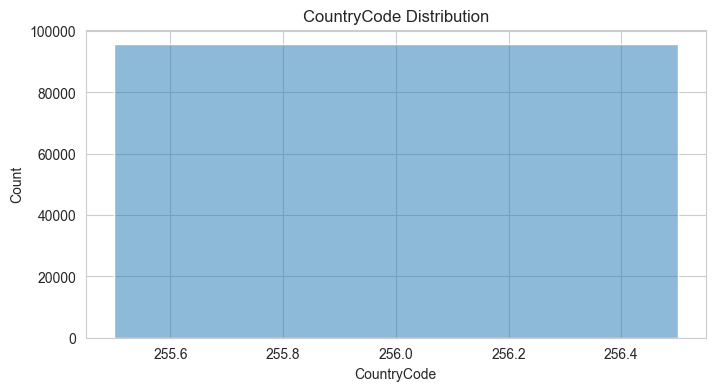

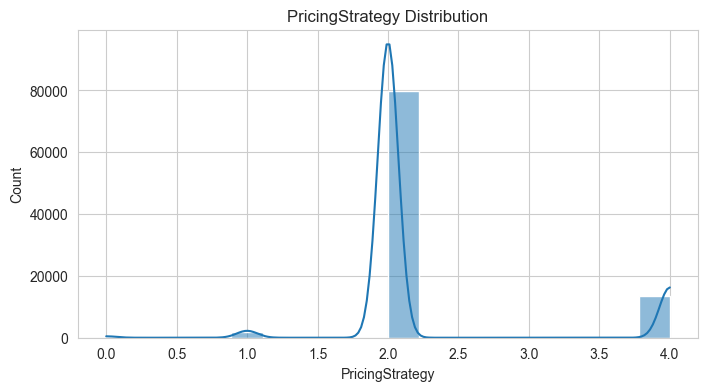

In [49]:
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

### Log-Transformed Transaction Value Distribution

The original transaction values are highly right-skewed due to the presence of a small number of extremely large transactions. To better visualize the distribution of typical transactions, a logarithmic transformation is applied.

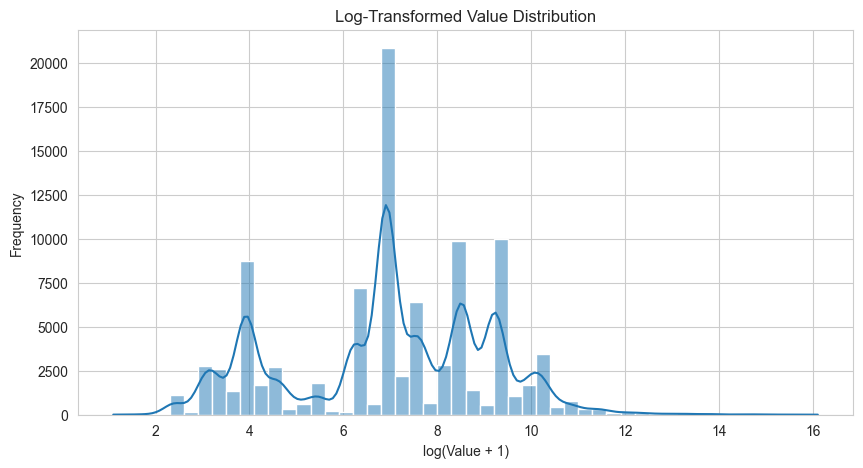

In [50]:
# import numpy as np

plt.figure(figsize=(10,5))

sns.histplot(
    np.log1p(df["Value"]),
    bins=50,
    kde=True
)

plt.title("Log-Transformed Value Distribution")
plt.xlabel("log(Value + 1)")
plt.ylabel("Frequency")

plt.show()

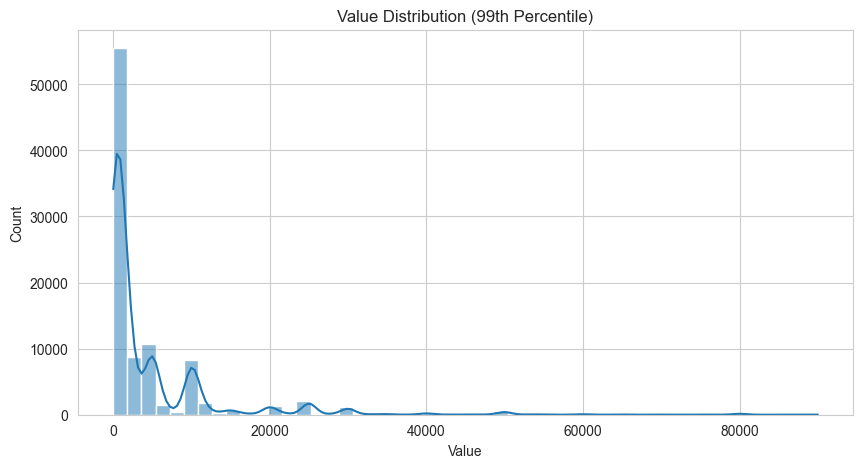

In [51]:
upper = df["Value"].quantile(0.99)

filtered = df[
    df["Value"] <= upper
]

plt.figure(figsize=(10,5))

sns.histplot(
    filtered["Value"],
    bins=50,
    kde=True
)

plt.title("Value Distribution (99th Percentile)")
plt.xlabel("Value")
plt.ylabel("Count")

plt.show()

In [52]:
df["TransactionStartTime"] = pd.to_datetime(
    df["TransactionStartTime"]
)

In [53]:
df["hour"] = df["TransactionStartTime"].dt.hour
df["day"] = df["TransactionStartTime"].dt.day
df["month"] = df["TransactionStartTime"].dt.month

<Axes: xlabel='hour', ylabel='count'>

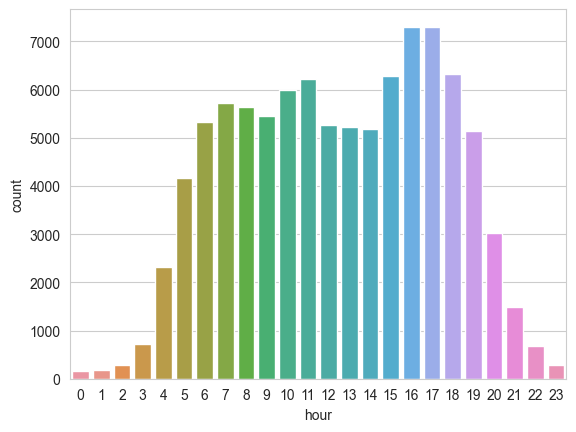

In [54]:
sns.countplot(x="hour", data=df)

### Product Category Distribution

This visualization shows the frequency of transactions across different product categories. Understanding the distribution of product categories helps identify the dominant transaction types and customer purchasing behavior on the platform.

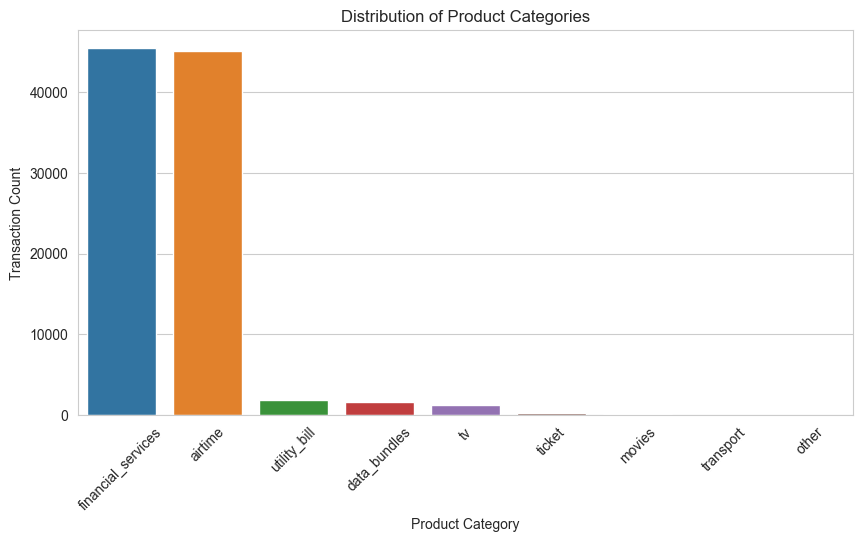

In [55]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='ProductCategory',
    order=df['ProductCategory'].value_counts().index
)

plt.title('Distribution of Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Transaction Count')
plt.xticks(rotation=45)

plt.show()

### Transaction Channel Distribution

This visualization illustrates the channels customers use to perform transactions. The analysis helps identify the most popular transaction channels and provides insights into customer interaction preferences.

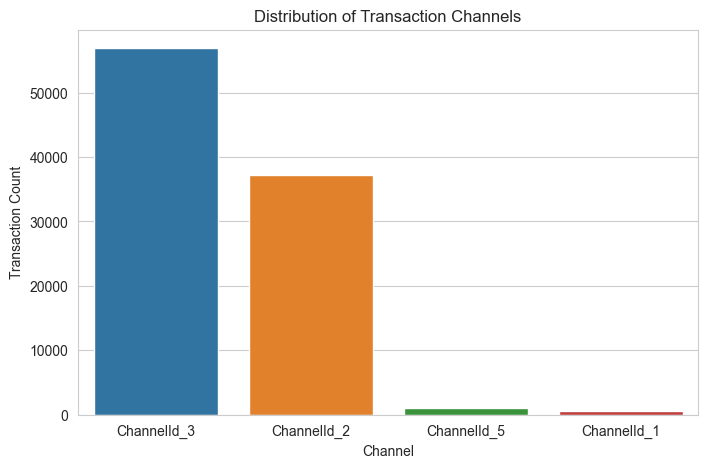

In [56]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='ChannelId',
    order=df['ChannelId'].value_counts().index
)

plt.title('Distribution of Transaction Channels')
plt.xlabel('Channel')
plt.ylabel('Transaction Count')

plt.show()

### Fraud Transaction Distribution

This plot shows the distribution of fraudulent and non-fraudulent transactions. Understanding class imbalance is important because highly imbalanced datasets require evaluation metrics beyond accuracy.

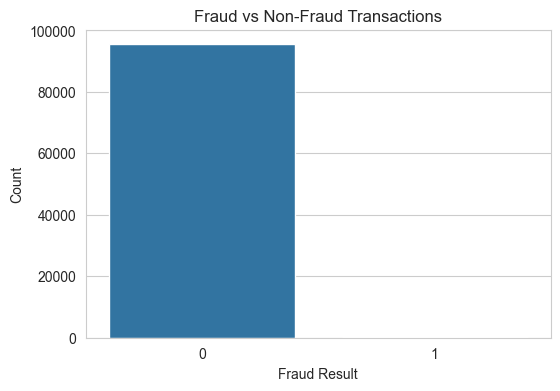

FraudResult
0    99.798248
1     0.201752
Name: proportion, dtype: float64


In [57]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='FraudResult'
)

plt.title('Fraud vs Non-Fraud Transactions')
plt.xlabel('Fraud Result')
plt.ylabel('Count')

plt.show()

print(df['FraudResult'].value_counts(normalize=True)*100)

### Correlation Analysis

Correlation analysis was conducted to examine relationships among numerical variables. Strong correlations may indicate redundant information, while weak correlations may reveal independent predictors useful for future modeling.

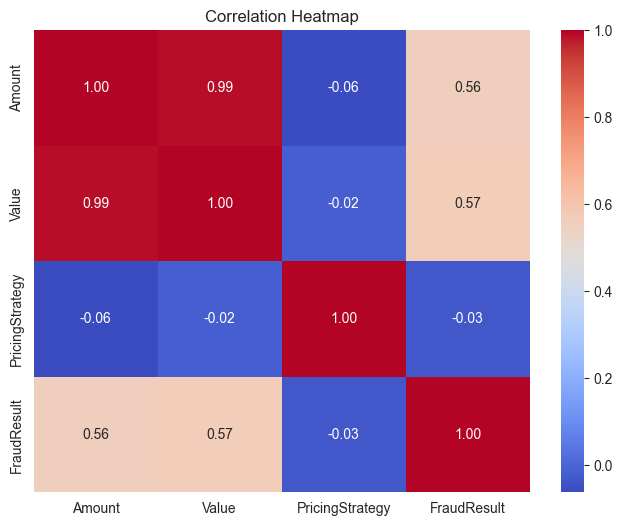

In [58]:
numeric_cols = [
    "Amount",
    "Value",
    "PricingStrategy",
    "FraudResult"
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### Missing Value Assessment

Missing value analysis was performed to evaluate data completeness. Identifying missing values helps determine whether imputation or data removal strategies are necessary before feature engineering and model development.

In [59]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage":
    round(df.isnull().mean()*100,2)
})

missing = missing[
    missing["Missing Count"] > 0
].sort_values(
    "Missing Count",
    ascending=False
)

missing

,Missing Count,Missing Percentage


In [60]:
if len(missing) > 0:

    plt.figure(figsize=(10,5))

    sns.barplot(
        x=missing.index,
        y=missing["Missing Count"]
    )

    plt.xticks(rotation=90)

    plt.title("Missing Values by Feature")

    plt.show()

else:
    print("No missing values detected.")

No missing values detected.


### Proposed Imputation Strategy

For future feature engineering and model training:

- Numerical variables will be imputed using the median value to reduce sensitivity to outliers.
- Categorical variables will be imputed using the most frequent category.
- Features with excessive missingness (if encountered in future datasets) will be evaluated for removal.

The current dataset exhibits strong completeness and therefore requires minimal imputation effort.

### Outlier Detection

Boxplots were used to identify extreme transaction values. Financial transaction datasets often contain large-value transactions that appear as outliers. Understanding these observations is important when selecting scaling and transformation techniques.

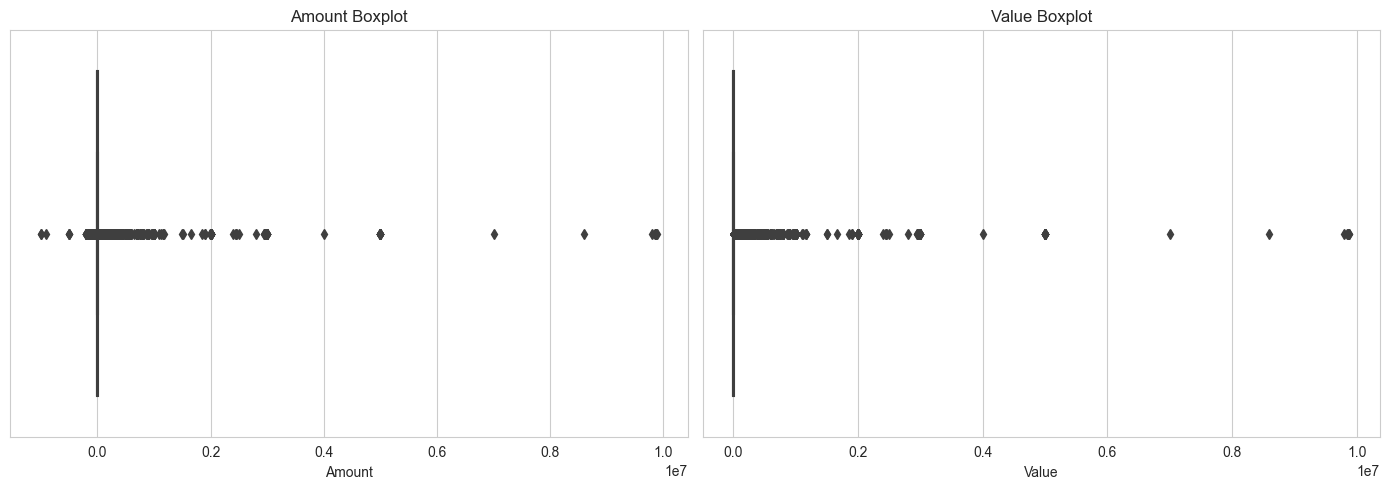

In [61]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(x=df["Amount"], ax=ax[0])
ax[0].set_title("Amount Boxplot")

sns.boxplot(x=df["Value"], ax=ax[1])
ax[1].set_title("Value Boxplot")

plt.tight_layout()
plt.show()

In [62]:
Q1 = df["Amount"].quantile(0.25)
Q3 = df["Amount"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Amount"] < lower) |
    (df["Amount"] > upper)
]

print("Number of Outliers:", len(outliers))
print("Percentage:",
      round(len(outliers)/len(df)*100,2),
      "%")

Number of Outliers: 24441
Percentage: 25.55 %


### Interpretation

The boxplots reveal the presence of substantial outliers in both Amount and Value. These observations are expected in financial transaction data where a small number of transactions account for very large monetary values. Rather than removing these observations, scaling techniques such as StandardScaler will be considered during feature engineering to preserve potentially valuable information.

## Numerical Summary Statistics

Summary statistics were computed to understand the central tendency, variability, and range of numerical variables.

In [63]:
numerical_summary = (
    df[
        [
            "Amount",
            "Value",
            "PricingStrategy",
            "FraudResult"
        ]
    ]
    .describe()
    .T
    .round(2)
)

display(numerical_summary)

,count,mean,std,min,25%,50%,75%,max
Amount,95662.0,6717.85,123306.80,-1000000.0,-50.0,1000.0,2800.0,9880000.0
Value,95662.0,9900.58,123122.09,2.0,275.0,1000.0,5000.0,9880000.0
PricingStrategy,95662.0,2.26,0.73,0.0,2.0,2.0,2.0,4.0
FraudResult,95662.0,0.00,0.04,0.0,0.0,0.0,0.0,1.0


The summary statistics indicate substantial variability in transaction amounts and values. The large gap between the mean and median transaction amounts suggests a highly right-skewed distribution, which is typical in financial transaction datasets. Fraudulent transactions represent a very small proportion of the dataset, indicating a highly imbalanced classification problem.

### Transaction Channel Distribution

This visualization illustrates the channels customers use to perform transactions. The analysis helps identify the most popular transaction channels and provides insights into customer interaction preferences.

# Key Insights

1. The dataset contains 95,662 transaction records with no duplicate observations, indicating good overall data quality.

2. Transaction amounts are highly right-skewed, with a median value of 1,000 and a maximum value of 9,880,000, suggesting the presence of significant outliers and a small number of very large transactions.

3. Fraudulent transactions account for only approximately 0.2% of all transactions, creating a highly imbalanced classification problem that requires appropriate evaluation metrics beyond accuracy.

4. CountryCode contains only a single value (256) across all observations, indicating no geographical variation and limited predictive usefulness.

5. The dataset captures repeated customer interactions over time, making customer-level aggregation and behavioral feature engineering suitable approaches for constructing a credit-risk proxy variable.